In [66]:
import logging
import os
import numpy as np
import matplotlib.pyplot
import matplotlib.pyplot as plt
import time
from typing import List, Tuple, Dict
import torch.nn.functional as F
from IPython.display import display, clear_output
import math
import torch
import argparse
from datetime import datetime
from torch.utils.data import DataLoader
from torch.nn import init
from torch import nn
import shelve
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
from logging.handlers import RotatingFileHandler
from mpl_toolkits.axes_grid1 import ImageGrid
from torchdiffeq import odeint
from torch.utils.data import Dataset
import h5py
import glob
import random
from netCDF4 import Dataset as netCDFDataset
from scipy import sparse as sp
from scipy import sparse
from scipy.sparse import spdiags
from scipy.sparse import linalg
from scipy.sparse.linalg import spsolve
from scipy.io import savemat,loadmat
import scipy.integrate as integrate
from scipy.special import iv
from functools import partial 
%matplotlib inline

In [67]:
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = "cuda"

In [68]:
def set_rdm_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_mgrid(sidelen, vmin=-1, vmax=1, dim=2):
    """
    Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int
    """
    if isinstance(sidelen, int):
        tensors = tuple(dim * [torch.linspace(vmin, vmax, steps=sidelen)])
    elif isinstance(sidelen, (list, tuple)):
        if isinstance(vmin, (list, tuple)) and isinstance(vmax, (list, tuple)):
            tensors = tuple([torch.linspace(mi, ma, steps=l) for mi, ma, l in zip(vmin, vmax, sidelen)])
        else:
            tensors = tuple([torch.linspace(vmin, vmax, steps=l) for l in sidelen])
    mgrid = torch.stack(torch.meshgrid(*tensors, indexing='xy'), dim=-1)
    return mgrid

def get_subset_indices(shape, num):
    """
    Generates subset indices for each dimension using linspace.
    shape: tuple
    num: int or list/tuple
    """
    if isinstance(num, int):
        num = [num] * len(shape)
    
    indices = [np.linspace(0, s-1, n, endpoint=True, dtype=int) for s, n in zip(shape, num)]
    return np.meshgrid(*indices, indexing='ij')

def apply_indices(data, indices, lag=0):
    """
    
    Applies subset indices to a tensor with a specified lag.
    data: torch.Tensor
    indices: list of np.ndarray
    lag: (int) determines how many leading dimensions of the tensor data should be skipped (i.e., remain unaffected) when applying the indices.
    """
    selected = [torch.tensor(idx, dtype=torch.long) for idx in indices]
    slices = [slice(None)] * lag + selected + [slice(None)]  if len(indices) == 2 else [slice(None)] * lag + selected
    new_data = data[tuple(slices)]
    
    # Reshape the data to the desired shape
    new_shape = list(data.shape[:lag]) + list(indices[0].shape) + list(data.shape[lag+len(indices):])
    #print("new_shape", new_shape)
    return new_data.reshape(new_shape)

In [46]:
import torch

def prepare_physics_inputs(args, batch, device):

    state_dim = args.state_dim

    coords = batch["coords"].to(device).float()              # [Nx, 3]
    inner_coords = batch["inner_coords"].to(device).float()  # [Nx, 3]
    tau = batch["t"].to(device).float()                      # [Nt]
    term_coords = batch["term_coords"].to(device).float()    # [Nterm, 3]
    term_t = batch["term_t"].to(device).float()              # [1]

    if coords.ndim != 2 or coords.shape[-1] != 3:
        raise ValueError(f"coords must have shape [Nx, 3], got {tuple(coords.shape)}")
    if inner_coords.ndim != 2 or inner_coords.shape[-1] != 3:
        raise ValueError(f"inner_coords must have shape [Nx, 3], got {tuple(inner_coords.shape)}")
    if tau.ndim != 1:
        raise ValueError(f"t must have shape [Nt], got {tuple(tau.shape)}")
    if term_coords.ndim != 2 or term_coords.shape[-1] != 3:
        raise ValueError(f"term_coords must have shape [Nterm, 3], got {tuple(term_coords.shape)}")
    if term_t.ndim != 1 or term_t.numel() != 1:
        raise ValueError(f"term_t must have shape [1], got {tuple(term_t.shape)}")

    b_size = 1
    t_size = tau.shape[0]
    n_coords = coords.shape[0]
    n_inner = inner_coords.shape[0]
    n_term = term_coords.shape[0]
    coord_dim = 3
    coords_exp = coords.unsqueeze(0).unsqueeze(0).unsqueeze(-2).expand(
        b_size, t_size, n_coords, state_dim, coord_dim
    )  # [1, Nt, Nx, S, 3]

    inner_coords_exp = inner_coords.unsqueeze(0).unsqueeze(0).unsqueeze(-2).expand(
        b_size, t_size, n_inner, state_dim, coord_dim
    )  # [1, Nt, Ninner, S, 3]

    tau_exp = tau.view(1, t_size, 1, 1, 1).expand(
        b_size, t_size, n_coords, state_dim, 1
    )  # [1, Nt, Nx, S, 1]

    tau_inner_exp = tau.view(1, t_size, 1, 1, 1).expand(
        b_size, t_size, n_inner, state_dim, 1
    )  # [1, Nt, Ninner, S, 1]

    xt = torch.cat([coords_exp, tau_exp], dim=-1).detach().requires_grad_(True)
    xt_in = torch.cat([inner_coords_exp, tau_inner_exp], dim=-1).detach().requires_grad_(True)

    term_coords_exp = term_coords.unsqueeze(0).unsqueeze(0).unsqueeze(-2).expand(
        b_size, 1, n_term, state_dim, coord_dim
    )  # [1, 1, Nterm, S, 3]

    term_t_exp = term_t.view(1, 1, 1, 1, 1).expand(
        b_size, 1, n_term, state_dim, 1
    )  # [1, 1, Nterm, S, 1]

    xt_term = torch.cat([term_coords_exp, term_t_exp], dim=-1).detach().requires_grad_(True)

    pars = torch.empty(b_size, 0, device=device)
    pars_org = pars.clone()
    par_id = torch.zeros(b_size, dtype=torch.long, device=device)

    batch_vars = {
        "t": tau,                       # reverse-time grid tau
        "xt": xt,                       # [1, Nt, Nx, S, 4]
        "xt_in": xt_in,                 # same as xt for now
        "xt_term": xt_term,             # [1, 1, Nterm, S, 4]
        "coords": coords,
        "inner_coords": inner_coords,
        "term_coords": term_coords,
        "term_t": term_t,
        "b_size": b_size,
        "t_size": t_size,
        "t_inner": t_size,
        "t_term": 1,
        "coord_dim": coord_dim,
        "state_dim": state_dim,
        "spatial_shape": (n_coords,),
        "inner_spatial_shape": (n_inner,),
        "term_spatial_shape": (n_term,),
        "num_spatial_dims": 1,
        "pars": pars,
        "pars_org": pars_org,
        "par_id": par_id,
        "init_cond": None,
    }

    return batch_vars

In [47]:
class BasePhysicsDataset(Dataset):
    def __init__(
        self,
        param,
        size,
        t_horizon,
        nt,
        group="train",
        n_frames_train=None,
    ):
        super().__init__()

        self.param = param
        self.group = group
        self.size = size
        self.t_horizon = float(t_horizon)
        self.nt = int(nt)
        self.n_frames_train = n_frames_train if n_frames_train is not None else self.nt

        self.coord_dim = int(param["ndim"])
        self.state_dim = int(param.get("state_dim", 1))

        self.mu_lst = self.get_parameter_list()
        self.n_seq = len(self.mu_lst)

        self.coords = self.build_coords()
        self.inner_coords = self.build_inner_coords(self.coords)

    def __len__(self):
        return self.n_seq

    def get_parameter_list(self):
        raise NotImplementedError

    def build_coords(self):
        raise NotImplementedError

    def build_inner_coords(self, coords):
        raise NotImplementedError

    def get_time_grid(self):
        if self.group in ("train", "short_ts"):
            return torch.linspace(0, self.t_horizon, self.nt + 1).float()[: self.n_frames_train + 1]
        return torch.linspace(0, self.t_horizon, self.nt + 1).float()

    def get_init_func(self, mu):
        raise NotImplementedError

    def __getitem__(self, index):
        mu = self.mu_lst[index]
        t = self.get_time_grid()
        init_func = self.get_init_func(mu)
        init_cond = init_func(self.coords)

        return {
            "t": t,
            "par_id": torch.tensor(index),
            "pars": torch.tensor(mu).float(),
            "pars_org": torch.tensor(mu).float(),
            "coords": self.coords.float(),
            "inner_coords": self.inner_coords.float(),
            "init_cond": init_cond.float(),
        }

class BaseResidual(nn.Module):
    def __init__(self):
        super().__init__()

    def residual(self, model, U, xt, params, states_in=None, d_states=None, ddU=None):
        raise NotImplementedError

class BaseAnsatz:
    def __init__(self, dataset=None, device=None):
        self.dataset = dataset
        self.device = device

    def get_ic(self):
        return 0

    def get_bc(self):
        return 0

    def decoder_input(self, xt, ret_type=None):
        return xt

    def __call__(self, model, xt, U_raw, params=None, ret_type=None):
        return U_raw

class BaseProblem(nn.Module):
    branch_names = ("solution",)

    def __init__(self, args, train_dataset, aux_branch_names=()):
        super().__init__()
        self.args = args
        self.train_dataset = train_dataset
        self.aux_branch_names = tuple(aux_branch_names)
        self.branch_names = ("solution",) + self.aux_branch_names
        self.criterion = nn.MSELoss()
        self.branch_init_codes = nn.ParameterDict()

    def setup_trainable_parameters(self, device):
        self.branch_init_codes = nn.ParameterDict()

    def trainable_parameters(self):
        return list(self.branch_init_codes.parameters())

    def init_solution_latent(self, model, batch_dict):
        b_size = batch_dict["b_size"]
        device = batch_dict["xt"].device
        return torch.zeros(b_size, model.latent_width, device=device)

    def init_aux_latent(self, name, model, batch_dict):
        b_size = batch_dict["b_size"]
        device = batch_dict["xt"].device

        if name in self.branch_init_codes:
            par_id = batch_dict["par_id"]
            return self.branch_init_codes[name][par_id]

        return torch.zeros(b_size, model.latent_width, device=device)

    def init_latents(self, model, batch_dict):
        out = {"solution": self.init_solution_latent(model, batch_dict)}
        for name in self.aux_branch_names:
            out[name] = self.init_aux_latent(name, model, batch_dict)
        return out

    def decode_solution(self, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]
        return model.decoder(xt, latents_full["solution"], params=pars_org)

    def decode_aux_branch(self, name, net, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]
        return net(xt, latents_full[name], params=pars_org, ret_type="deriv")

    def decode_outputs(self, model, batch_dict, latents_full, eval_mode="train"):
        decoded = {
            "solution": self.decode_solution(model, batch_dict, latents_full, eval_mode=eval_mode)
        }
        for name, net in model.aux_decoders.items():
            if name in latents_full:
                decoded[name] = self.decode_aux_branch(name, net, model, batch_dict, latents_full, eval_mode=eval_mode)
        return decoded

    def make_zero_loss_dict(self, device):
        zero = torch.tensor(0.0, device=device)
        return {
            "loss_pinn": zero,
            "loss_ic": zero,
            "loss_bc": zero,
        }

    def compute_losses(self, model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode="train"):
        raise NotImplementedError

    def adapt_latents(self, model, batch_dict, num_steps=100):
        return None

In [48]:
class Air3DDataset(Dataset):
    def __init__(
        self,
        num_batches,
        nx_sample,
        nt,
        T=1.0,
        x1_bounds=(-1.0, 1.0),
        x2_bounds=(-1.0, 1.0),
        x3_bounds=(-math.pi, math.pi),
        n_term=None,
        tau_max=None,
        scale_to_minus1_1=False,
    ):
        super().__init__()

        self.num_batches = int(num_batches)
        self.nx_sample = int(nx_sample)
        self.nt = int(nt)
        self.T = float(T)

        self.x1_bounds = tuple(x1_bounds)
        self.x2_bounds = tuple(x2_bounds)
        self.x3_bounds = tuple(x3_bounds)

        self.n_term = int(n_term) if n_term is not None else int(nx_sample)
        self.tau_max = float(T if tau_max is None else tau_max)
        self.scale_to_minus1_1 = bool(scale_to_minus1_1)

        self.coord_dim = 3
        self.state_dim = 1
        self.npars = 0

        if not (0.0 <= self.tau_max <= self.T):
            raise ValueError(f"tau_max must be in [0, T], got tau_max={self.tau_max}, T={self.T}")

    def __len__(self):
        return self.num_batches

    def set_tau_max(self, tau_max):
        tau_max = float(tau_max)
        if not (0.0 <= tau_max <= self.T):
            raise ValueError(f"tau_max must be in [0, T], got tau_max={tau_max}, T={self.T}")
        self.tau_max = tau_max

    def _sample_uniform(self, n, bounds):
        lo, hi = bounds
        return lo + (hi - lo) * torch.rand(n, 1)

    def _sample_states_unscaled(self, n):
        x1 = self._sample_uniform(n, self.x1_bounds)
        x2 = self._sample_uniform(n, self.x2_bounds)
        x3 = self._sample_uniform(n, self.x3_bounds)
        return torch.cat([x1, x2, x3], dim=-1)

    def _scale_states(self, x):
        if not self.scale_to_minus1_1:
            return x

        bounds = torch.tensor(
            [self.x1_bounds, self.x2_bounds, self.x3_bounds],
            dtype=x.dtype,
            device=x.device,
        )  # [3, 2]

        lo = bounds[:, 0]
        hi = bounds[:, 1]
        return 2.0 * (x - lo) / (hi - lo) - 1.0

    def _sample_states(self, n):
        x = self._sample_states_unscaled(n)
        return self._scale_states(x)

    def _make_tau_grid(self):
        if self.tau_max <= 0.0:
            return torch.zeros(1).float()
    
        return torch.linspace(0.0, self.tau_max, self.nt).float()

    @staticmethod
    def target_fn(x, beta=0.25):
        return torch.sqrt(x[..., 0] ** 2 + x[..., 1] ** 2 + 1e-12) - beta

    def __getitem__(self, index):
        coords = self._sample_states(self.nx_sample)         # [Nx, 3]
        inner_coords = coords.clone()                        # same for Air3D
        tau_grid = self._make_tau_grid()                     # [Nt]

        term_coords = self._sample_states(self.n_term)       # [Nterm, 3]
        term_t = torch.zeros(1).float()                      # tau = 0

        return {
            "coords": coords.float(),
            "inner_coords": inner_coords.float(),
            "t": tau_grid.float(),
            "term_coords": term_coords.float(),
            "term_t": term_t,
        }

In [60]:
class Air3DResidual(BaseResidual):
    def __init__(self, ve=0.75, vp=0.75, wmax=3.0, beta=0.25, eps=1e-12):
        super().__init__()
        self.ve = float(ve)
        self.vp = float(vp)
        self.wmax = float(wmax)
        self.beta = float(beta)
        self.eps = float(eps)

    def target_fn(self, x):
        return torch.sqrt(x[..., 0] ** 2 + x[..., 1] ** 2 + self.eps) - self.beta

    def hamiltonian(self, x, grad_x):
        x1 = x[..., 0]
        x2 = x[..., 1]
        x3 = x[..., 2]

        p1 = grad_x[..., 0]
        p2 = grad_x[..., 1]
        p3 = grad_x[..., 2]

        H = (
            p1 * (-self.ve + self.vp * torch.cos(x3))
            + p2 * (self.vp * torch.sin(x3))
            - self.wmax * torch.abs(p1 * x2 - p2 * x1 - p3)
            + self.wmax * p3
        )
        return H

    def residual(self, model, U, xt, params=None, states_in=None, d_states=None, ddU=None):
        V = U[..., 0]  # [B, Nt, Nx]

        if d_states is not None and states_in is not None:
            dV_dxt, dV_dalpha = torch.autograd.grad(
                U,
                [xt, states_in],
                grad_outputs=torch.ones_like(U),
                retain_graph=True,
                create_graph=True,
            )

            # Spatial gradient wrt x = first 3 coordinates
            grad_x = dV_dxt[..., 0, :3]  # [B, Nt, Nx, 3]

            dV_dtau_latent = torch.einsum('...sc,...sc->...s', dV_dalpha, d_states)
            V_tau = dV_dtau_latent[..., 0]

            if xt.shape[-1] >= 4:
                V_tau = V_tau + dV_dxt[..., 0, 3]

        else:
            # Direct autodiff wrt [x1, x2, x3, tau]
            dV_dxt = torch.autograd.grad(
                U,
                xt,
                grad_outputs=torch.ones_like(U),
                retain_graph=True,
                create_graph=True,
            )[0]

            grad_x = dV_dxt[..., 0, :3]   # [B, Nt, Nx, 3]
            V_tau = dV_dxt[..., 0, 3]     # [B, Nt, Nx]

        x = xt[..., 0, :3]                # [B, Nt, Nx, 3]
        l_x = self.target_fn(x)           # [B, Nt, Nx]
        H = self.hamiltonian(x, grad_x)   # [B, Nt, Nx]

        # Reverse-time conversion: V_t = -V_tau
        V_t_phys = -V_tau

        # HJI-VI residual:
        # min( V_t + H, l(x) - V ) = 0
        r = torch.minimum(V_t_phys + H, l_x - V)
        return r

In [52]:
class Air3DProblem(BaseProblem):
    branch_names = ("solution",)

    def __init__(self, args, train_dataset):
        super().__init__(args, train_dataset, aux_branch_names=())
        self.args = args
        self.train_dataset = train_dataset
        self.criterion = nn.MSELoss()

    def setup_trainable_parameters(self, device):
        # No aux initial codes needed for Air3D first-order HJI
        self.branch_init_codes = nn.ParameterDict()

    def trainable_parameters(self):
        return []

    def init_solution_latent(self, model, batch_dict):
        b_size = batch_dict["b_size"]
        device = batch_dict["xt"].device
        return torch.zeros(b_size, model.latent_width, device=device)

    def init_latents(self, model, batch_dict):
        return {"solution": self.init_solution_latent(model, batch_dict)}

    def decode_solution(self, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]
        return model.decoder(xt, latents_full["solution"], params=pars_org)

    def decode_terminal(self, model, batch_dict, latent_init):
        xt_term = batch_dict["xt_term"]  # [B, 1, Nterm, S, 4]
        b_size = batch_dict["b_size"]
        n_term = batch_dict["term_spatial_shape"][0]
        state_dim = batch_dict["state_dim"]

        latent_term = latent_init["solution"].view(
            b_size, 1, 1, state_dim, model.latent_dim
        ).expand(
            b_size, 1, n_term, state_dim, model.latent_dim
        )

        pars_org = batch_dict["pars_org"]
        return model.decoder(xt_term, latent_term, params=pars_org)

    def decode_outputs(self, model, batch_dict, latents_full, eval_mode="train"):
        decoded = {
            "solution": self.decode_solution(model, batch_dict, latents_full, eval_mode=eval_mode)
        }
        return decoded

    def compute_losses(
        self,
        model,
        batch_dict,
        decoded,
        latents_full,
        latents_inner,
        latents_d_inner,
        eval_mode="train",
    ):
        device = decoded["solution"].device
        zero = torch.tensor(0.0, device=device)

        loss_dict = {
            "loss_pinn": zero,
            "loss_term": zero,
            "loss_ic": zero,  
            "loss_bc": zero,   
        }

        latent_init = {
            "solution": latents_full["solution"][:, 0, 0, 0, :]
        }  # [B, latent_width]

        V_term = self.decode_terminal(model, batch_dict, latent_init)   # [B, 1, Nterm, S]
        x_term = batch_dict["xt_term"][..., 0, :3]                      # [B, 1, Nterm, 3]
        l_term = model.decoder.pde.target_fn(x_term).unsqueeze(-1)      # [B, 1, Nterm, 1]

        loss_term = self.criterion(V_term, l_term)
        loss_dict["loss_term"] = loss_term
        xt_in = batch_dict["xt_in"]
        pars_org = batch_dict["pars_org"]

        V_in = model.decoder(
            xt_in,
            latents_inner["solution"],
            params=pars_org,
        )

        loss_pinn, _ = model.decoder.pinn_loss(
            V_in,
            xt_in,
            pars_org,
            latents_inner["solution"],
            latents_d_inner["solution"],
        )

        loss_dict["loss_pinn"] = loss_pinn
        return loss_dict

    def adapt_latents(self, model, batch_dict, num_steps=100):
        return None

In [56]:
class Swish(nn.Module):
    def __init__(self, beta=0.5):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor([beta]))

    def forward(self, x):
        return (x * torch.sigmoid_(x * F.softplus(self.beta))).div_(1.1)

class SirenLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=30.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.is_first = is_first
        self.omega_0 = omega_0

        self.linear = nn.Linear(in_features, out_features)
        self.reset_parameters()

    def reset_parameters(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.in_features
            else:
                bound = math.sqrt(6.0 / self.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


def create_inr_pnode(args, problem, solution_decoder, ode_func_net, aux_decoders=None, ode_solver=odeint):
    if aux_decoders is None:
        aux_decoders = nn.ModuleDict()

    model = INR_PNODE(
        args=args,
        ode_func_net=ode_func_net,
        solution_decoder=solution_decoder,
        problem=problem,
        ode_solver=ode_solver,
        aux_decoders=aux_decoders,
    )

    lr = args.lr
    optimizers = {
        "optim_solution_decoder": torch.optim.Adam(model.solution_decoder.parameters(), lr=lr),
        "optim_ode_func_net": torch.optim.Adam(model.ode_func_net.parameters(), lr=lr / 10),
    }

    aux_params = [p for m in model.aux_decoders.values() for p in m.parameters()]
    if len(aux_params) > 0:
        optimizers["optim_aux_decoders"] = torch.optim.Adam(aux_params, lr=lr)

    if hasattr(problem, "trainable_parameters"):
        extra_params = list(problem.trainable_parameters())
        if len(extra_params) > 0:
            optimizers["optim_problem"] = torch.optim.Adam(extra_params, lr=lr / 10)

    return model, optimizers


class LossManager(nn.Module):
    def __init__(self, problem, pi_loss=True, loss_weights=None):
        super().__init__()
        self.problem = problem

        if loss_weights is not None:
            self.loss_weights = loss_weights
        else:
            self.loss_weights = {
                "term": 1.0,
                "pinn": 1.0,
                "ic": 0.0,
                "bc": 0.0,
            }

    def _to_tensor_scalar(self, v, device):
        if isinstance(v, torch.Tensor):
            return v.mean()
        return torch.tensor(float(v), device=device)

    def compute_all_losses(self, batch, model_output, loss_dict):
        zero = torch.tensor(0.0, device=model_output.device)
        results = dict(loss_dict) if loss_dict is not None else {}

        loss_train = zero
        for name, weight in self.loss_weights.items():
            key = name if name.startswith("loss_") else f"loss_{name}"
            value = results.get(key, zero)
            value = self._to_tensor_scalar(value, model_output.device)
            loss_train = loss_train + weight * value

        results["loss_train"] = loss_train
        results["params"] = batch.get("pars_org", None)
        return results


class MLP(nn.Module):
    def __init__(self, code_dim, hidden_dim, out_dim=None):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(code_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, code_dim if out_dim is None else out_dim)
        )

    def forward(self, x):
        return self.model(x)


class DerivativePNODE(nn.Module):
    def __init__(self, state_dim, latent_dim, hidden_dim, num_params, auxilliary_dim=1):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = latent_dim * state_dim * auxilliary_dim
        self.model = MLP(self.input_dim + num_params, hidden_dim)
        self.num_params = num_params
        self.params = None

    def set_params(self, new_params):
        self.params = new_params

    def forward(self, t, u):
        out = self.model(u)
        if self.num_params > 0:
            if self.params is None:
                raise ValueError("DerivativePNODE params were not set before forward().")
            out[..., -self.num_params:] = self.params
        return out


class Derivative(nn.Module):
    def __init__(self, state_dim, latent_dim, hidden_dim):
        super().__init__()
        input_dim = state_dim * latent_dim
        self.model = MLP(input_dim, hidden_dim)

    def forward(self, t, u):
        return self.model(u)


# class Decoder(nn.Module):
#     def __init__(self, state_dim, hidden_dim, latent_dim, coordinate_dim, out_dim, num_layers, input_scale=64):
#         super().__init__()
#         self.state_dim = state_dim
#         self.hidden_dim = hidden_dim
#         self.latent_dim = latent_dim
#         self.coordinate_dim = coordinate_dim
#         self.out_dim = out_dim
#         self.model = FourierNet(self.coordinate_dim, self.hidden_dim, self.latent_dim, self.out_dim, num_layers, input_scale=input_scale)

#     def forward(self, x, codes=None):
#         if codes is None:
#             return self.model(x)
#         return self.model(x, codes)

class Decoder(nn.Module):
    def __init__(
        self,
        state_dim,
        hidden_dim,
        latent_dim,
        coordinate_dim,
        out_dim,
        num_layers,
        omega_0=30.0,
        hidden_omega_0=30.0,
    ):
        super().__init__()
        self.state_dim = state_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.coordinate_dim = coordinate_dim
        self.out_dim = out_dim

        self.model = SirenNet(
            in_dim=self.coordinate_dim,
            hidden_dim=self.hidden_dim,
            code_dim=self.latent_dim,
            out_dim=self.out_dim,
            num_layers=num_layers,
            omega_0=omega_0,
            hidden_omega_0=hidden_omega_0,
        )

    def forward(self, x, codes=None):
        if codes is None:
            return self.model(x)
        return self.model(x, codes)


# class MFNBase(nn.Module):
#     def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers):
#         super().__init__()
#         self.conditioning = nn.ModuleList(
#             [AdditiveConditioning(in_dim, code_dim, hidden_dim)] +
#             [AdditiveConditioning(hidden_dim, code_dim, hidden_dim) for _ in range(num_layers)]
#         )
#         self.conditioning_out = nn.Linear(hidden_dim, out_dim)

#     def forward(self, x, code):
#         out = self.filters[0](x) * self.conditioning[0](x * 0., code)
#         for i in range(1, len(self.filters)):
#             out = self.filters[i](x) * self.conditioning[i](out, code)

#         out = self.conditioning_out(out)
#         if out.shape[-1] == 1:
#             out = out.squeeze(-1)
#         return out, x

class MFNBase(nn.Module):
    def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers):
        super().__init__()
        self.conditioning = nn.ModuleList(
            [AdditiveConditioning(in_dim, code_dim, hidden_dim)] +
            [AdditiveConditioning(hidden_dim, code_dim, hidden_dim) for _ in range(num_layers)]
        )
        self.conditioning_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, code):
        out = self.filters[0](x) + self.conditioning[0](x * 0.0, code)
        for i in range(1, len(self.filters)):
            out = self.filters[i](x) + self.conditioning[i](out, code)

        out = self.conditioning_out(out)
        if out.shape[-1] == 1:
            out = out.squeeze(-1)
        return out, x
        
class SirenNet(MFNBase):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        code_dim,
        out_dim,
        num_layers=3,
        omega_0=30.0,
        hidden_omega_0=30.0,
    ):
        super().__init__(in_dim, hidden_dim, code_dim, out_dim, num_layers)

        self.filters = nn.ModuleList()

        # First layer
        self.filters.append(
            SirenLayer(
                in_features=in_dim,
                out_features=hidden_dim,
                is_first=True,
                omega_0=omega_0,
            )
        )

        # Hidden layers
        for _ in range(num_layers):
            self.filters.append(
                SirenLayer(
                    in_features=in_dim,
                    out_features=hidden_dim,
                    is_first=False,
                    omega_0=hidden_omega_0,
                )
            )

# class FourierLayer(nn.Module):
#     def __init__(self, in_features, out_features, weight_scale):
#         super().__init__()
#         self.weight = nn.parameter.Parameter(torch.empty((out_features, in_features)))
#         self.weight_scale = weight_scale
#         self.reset_parameters()

#     def reset_parameters(self):
#         nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

#     def forward(self, x):
#         return torch.cat([
#             torch.sin(F.linear(x, self.weight * self.weight_scale)),
#             torch.cos(F.linear(x, self.weight * self.weight_scale))
#         ], dim=-1)


# class FourierNet(MFNBase):
#     def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers=3, input_scale=256.0):
#         super().__init__(in_dim, hidden_dim, code_dim, out_dim, num_layers)
#         self.filters = nn.ModuleList(
#             [FourierLayer(in_dim, hidden_dim // 2, input_scale / np.sqrt(num_layers + 1)) for _ in range(num_layers + 1)]
#         )

#     def get_filters_weight(self):
#         weights = []
#         for f in self.filters:
#             weights.append(f.weight)
#         return torch.cat(weights)


class AdditiveConditioning(nn.Module):
    def __init__(self, x, code, out):
        super().__init__()
        self.x = x
        self.code = code
        self.out = out
        self.A = nn.parameter.Parameter(torch.empty(self.out, self.code))
        self.B = nn.parameter.Parameter(torch.empty(self.out, self.x))
        self.bias = nn.parameter.Parameter(torch.empty(self.out))
        self.reset_parameters()

    def reset_parameters(self):
        bound = 1 / math.sqrt(self.x)
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.B, a=math.sqrt(5))
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x, code):
        code_transform = torch.einsum('...j,oj->...o', code, self.A)
        x_transform = torch.einsum('...i,oi->...o', x, self.B)
        return code_transform + x_transform + self.bias


class PINN(nn.Module):
    def __init__(self, decoder, pde, out_dim, ic_fn=None, ansatz=None):
        super().__init__()
        self.decoder = decoder
        self.pde = pde
        self.out_dim = out_dim
        self.ic_fn = ic_fn
        self.ansatz = ansatz
        self.loss = nn.MSELoss()
        self.loss_l1 = nn.L1Loss()

    def grad_wrt_coords(self, U, xt):
        return torch.autograd.grad(
            U, xt,
            grad_outputs=torch.ones_like(U),
            retain_graph=True,
            create_graph=True
        )[0]

    def pinn_loss(self, U, xt, params, states_in=None, d_states=None, ddU=None, truncate=None):
        residual = self.pde.residual(
            model=self,
            U=U,
            xt=xt,
            params=params,
            states_in=states_in,
            d_states=d_states,
            ddU=ddU
        )
        loss_pinn = torch.mean(residual ** 2)
        if truncate is None:
            loss_pinn_trunc = loss_pinn
        else:
            loss_pinn_trunc = torch.mean(residual[:, :truncate] ** 2)
        return loss_pinn, loss_pinn_trunc

    def get_ic(self):
        if self.ansatz is not None and hasattr(self.ansatz, "get_ic"):
            return self.ansatz.get_ic()
        return 0

    def get_bc(self):
        if self.ansatz is not None and hasattr(self.ansatz, "get_bc"):
            return self.ansatz.get_bc()
        return 0

    def forward(self, xt, latents, params=None, ret_type=None):
        if self.ansatz is not None and hasattr(self.ansatz, "decoder_input"):
            decoder_xt = self.ansatz.decoder_input(xt, ret_type=ret_type)
        else:
            # Air3D CNF-ROM: decoder sees only the state coordinates
            decoder_xt = xt[..., :self.decoder.coordinate_dim]

        U = self.decoder(decoder_xt, latents)[0]

        if self.ansatz is None or ret_type == "deriv":
            return U

        return self.ansatz(model=self, xt=xt, U_raw=U, params=params, ret_type=ret_type)


class INR_PNODE(nn.Module):
    def __init__(self, args, ode_func_net, solution_decoder, problem, ode_solver=odeint, aux_decoders=None):
        super().__init__()
        self.args = args
        self.device = args.device if hasattr(args, "device") else None

        self.ode_func_net = ode_func_net
        self.solution_decoder = solution_decoder
        self.decoder = solution_decoder

        self.problem = problem
        self.ode_solver = ode_solver
        self.aux_decoders = aux_decoders if aux_decoders is not None else nn.ModuleDict()

        self.loss_manager = LossManager(problem, pi_loss=args.pi_loss)
        self.criterion = nn.MSELoss()

        self.state_dim = args.state_dim
        self.latent_dim = args.code_dim
        self.num_params = args.npars
        self.branch_names = tuple(problem.branch_names)

        if len(self.branch_names) == 0 or self.branch_names[0] != "solution":
            raise ValueError("problem.branch_names must start with 'solution'")

        missing_aux = [name for name in self.branch_names[1:] if name not in self.aux_decoders]
        if len(missing_aux) > 0:
            raise ValueError(f"Missing aux decoders for branches: {missing_aux}")

    @property
    def latent_width(self):
        return self.state_dim * self.latent_dim

    def _prepare_batch(self, batch):
        return prepare_physics_inputs(self.args, batch, self.device)

    def grad_wrt_coords(self, Y, coords):
        return torch.autograd.grad(
            Y, coords,
            grad_outputs=torch.ones_like(Y),
            retain_graph=True,
            create_graph=True
        )[0]

    def concat_latents(self, latent_dict):
        return torch.cat([latent_dict[name] for name in self.branch_names], dim=-1)

    def unpack_latents(self, flattened_latents):
        out = {}
        start = 0
        for name in self.branch_names:
            end = start + self.latent_width
            out[name] = flattened_latents[..., start:end]
            start = end
        return out

    def expand_latents(self, latent_dict, batch_dict, inner=False, requires_grad=False):
        batch_size = batch_dict["b_size"]
        time_size = batch_dict["t_size"]
        spatial_shape = batch_dict["inner_spatial_shape"] if inner else batch_dict["spatial_shape"]
        num_spatial_dims = len(spatial_shape)

        expanded = {}
        for name, latent in latent_dict.items():
            latent = latent[:, :time_size]
            latent = latent.view(
                batch_size,
                time_size,
                *([1] * num_spatial_dims),
                self.state_dim,
                self.latent_dim,
            )
            latent = latent.expand(
                batch_size,
                time_size,
                *spatial_shape,
                self.state_dim,
                self.latent_dim,
            )
            if requires_grad:
                latent = latent.requires_grad_(True)
            expanded[name] = latent
        return expanded

    def solve_latent_trajectory(self, batch_dict, init_latents):
        time = batch_dict["t"]
        params = batch_dict["pars"]
        rtol = getattr(self.args, "rtol", 1e-7)
        atol = getattr(self.args, "atol", 1e-9)
        method = self.args.method

        y0_latent = self.concat_latents(init_latents)
        y0_augmented = torch.cat([y0_latent, params], dim=-1)

        if hasattr(self.ode_func_net, "set_params"):
            self.ode_func_net.set_params(params)

        latent_augmented = self.ode_solver(
            self.ode_func_net,
            y0_augmented,
            time,
            rtol=rtol,
            atol=atol,
            method=method
        )

        if self.num_params > 0:
            flat_latents = latent_augmented[..., :-self.num_params].permute(1, 0, 2).contiguous()
        else:
            flat_latents = latent_augmented.permute(1, 0, 2).contiguous()
        latent_trajectory = self.unpack_latents(flat_latents)
        
        ode_rhs = self.ode_func_net(time, latent_augmented)
        if self.num_params > 0:
            flat_d_latents = ode_rhs[..., :-self.num_params].permute(1, 0, 2).contiguous()
        else:
            flat_d_latents = ode_rhs.permute(1, 0, 2).contiguous()
        latent_d_trajectory = self.unpack_latents(flat_d_latents)

        return latent_trajectory, latent_d_trajectory

    def predict(self, batch, mode="predict"):
        batch_dict = self._prepare_batch(batch)
        init_latents = self.problem.init_latents(self, batch_dict)
        latent_trajectory, _ = self.solve_latent_trajectory(batch_dict, init_latents)
        latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
        decoded = self.problem.decode_outputs(
            model=self,
            batch_dict=batch_dict,
            latents_full=latents_full,
            eval_mode=mode,
        )
        return decoded["solution"]

    def data_reconstruction(self, batch, eval_mode="train", batch_dict=None):
        if batch_dict is None:
            batch_dict = self._prepare_batch(batch)

        init_latents = self.problem.init_latents(self, batch_dict)
        latent_trajectory, latent_d_trajectory = self.solve_latent_trajectory(batch_dict, init_latents)

        if eval_mode == "code":
            latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
            decoded = self.problem.decode_outputs(
                model=self,
                batch_dict=batch_dict,
                latents_full=latents_full,
                eval_mode=eval_mode,
            )
            return decoded["solution"], latents_full["solution"]

        latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
        latents_inner = self.expand_latents(latent_trajectory, batch_dict, inner=True, requires_grad=True)
        latents_d_inner = self.expand_latents(latent_d_trajectory, batch_dict, inner=True, requires_grad=False)

        decoded = self.problem.decode_outputs(
            model=self,
            batch_dict=batch_dict,
            latents_full=latents_full,
            eval_mode=eval_mode,
        )

        loss_dict = self.problem.compute_losses(
            model=self,
            batch_dict=batch_dict,
            decoded=decoded,
            latents_full=latents_full,
            latents_inner=latents_inner,
            latents_d_inner=latents_d_inner,
            eval_mode=eval_mode,
        )

        return decoded["solution"], loss_dict

    def eval_reconstruction(self, batch, n_steps=100):
        self.eval()

        modules_to_freeze = [self.solution_decoder, self.ode_func_net]
        modules_to_freeze += list(self.aux_decoders.values())

        prev_requires_grad = {}
        for m in modules_to_freeze:
            for p in m.parameters():
                prev_requires_grad[p] = p.requires_grad
                p.requires_grad_(False)

        batch_dict = self._prepare_batch(batch)

        adapted_latents = None
        if hasattr(self.problem, "adapt_latents"):
            adapted_latents = self.problem.adapt_latents(self, batch_dict, num_steps=n_steps)

        if adapted_latents is None:
            adapted_latents = self.problem.init_latents(self, batch_dict)

        with torch.no_grad():
            latent_trajectory, _ = self.solve_latent_trajectory(batch_dict, adapted_latents)
            latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
            decoded = self.problem.decode_outputs(
                model=self,
                batch_dict=batch_dict,
                latents_full=latents_full,
                eval_mode="eval",
            )
            model_output = decoded["solution"]

        for p, req in prev_requires_grad.items():
            p.requires_grad_(req)

        self.train()
        return model_output

    def compute_all_losses(self, batch, mode="train"):
        batch_dict = self._prepare_batch(batch)

        if mode == "visualization":
            model_output, _ = self.data_reconstruction(batch, eval_mode=mode, batch_dict=batch_dict)
            return model_output.detach().cpu().numpy()

        model_output, loss_dict = self.data_reconstruction(batch, eval_mode=mode, batch_dict=batch_dict)
        return self.loss_manager.compute_all_losses(batch_dict, model_output, loss_dict)

In [58]:
args = argparse.Namespace(
    dName='bg1d',
    checkpoint=None,
    meshType='coarse',
    setType=0,
    gpu=1,
    pi_loss=True,
    test_idx=None,
    mode='pnode',
    ic=1,
    bc=1,
    viz=1,
    input_scale=16.0,
    lr=1e-2,
    initType='Cecchi',
    cuda=None,
)
args.device = device
args.state_dim = 1
args.coord_dim = 3
args.code_dim =  512
args.latent_dim = args.code_dim
args.npars = 0
args.num_params = 0

args.hidden_c = 128
args.hidden_c_enc = 64
args.n_layers = 3
args.input_scale = 16.0
args.lr = 1e-3

args.method = "rk4"
args.rtol = 1e-7
args.atol = 1e-9

args.T = 1.0

args.ve = 0.75
args.vp = 0.75
args.wmax = 3.0
args.beta = 0.25

args.x1_bounds = (-1.0, 1.0)
args.x2_bounds = (-1.0, 1.0)
args.x3_bounds = (-math.pi, math.pi)

args.num_batches = 1000
args.nx_sample = 4096
args.n_term = 4096
args.nt = 64

set_rdm_seed(1)

dataset_tr = Air3DDataset(
    num_batches=args.num_batches,
    nx_sample=args.nx_sample,
    nt=args.nt,
    T=args.T,
    x1_bounds=args.x1_bounds,
    x2_bounds=args.x2_bounds,
    x3_bounds=args.x3_bounds,
    n_term=args.n_term,
    tau_max=0.0,             
    scale_to_minus1_1=False,
)

dataloader_tr = DataLoader(dataset_tr, batch_size=None, shuffle=False)

args.dataset_dict = {"train": dataset_tr}
args.dataloader_dict = {"train": dataloader_tr}
args.setName = "train"

args.params_dict = {
    "train": {
        "t_horizon": args.T,
        "nt": args.nt,
        "n_seq": 1,
    }
}

# ---------------------------------
# Decoder / PDE / problem
# ---------------------------------
# solution_decoder = PINN(
#     decoder=Decoder(
#         state_dim=args.state_dim,
#         hidden_dim=args.hidden_c_enc,
#         latent_dim=args.code_dim,
#         coordinate_dim=3,   # Air3D state is (x1, x2, x3)
#         out_dim=1,          # scalar value function V
#         num_layers=args.n_layers,
#         input_scale=args.input_scale,
#     ),
#     pde=Air3DResidual(
#         ve=args.ve,
#         vp=args.vp,
#         wmax=args.wmax,
#         beta=args.beta,
#     ),
#     out_dim=1,
#     ansatz=None,           
# )
solution_decoder = PINN(
    decoder=Decoder(
        state_dim=args.state_dim,
        hidden_dim=args.hidden_c_enc,
        latent_dim=args.code_dim,
        coordinate_dim=3,
        out_dim=1,
        num_layers=args.n_layers,
        omega_0=30.0,
        hidden_omega_0=30.0,
    ),
    pde=Air3DResidual(
        ve=args.ve,
        vp=args.vp,
        wmax=args.wmax,
        beta=args.beta,
    ),
    out_dim=1,
    ansatz=None,
)

problem = Air3DProblem(args, dataset_tr)
problem.setup_trainable_parameters(device)

ode_func_net = DerivativePNODE(
    state_dim=args.state_dim,
    latent_dim=args.code_dim,
    hidden_dim=args.hidden_c,
    num_params=0,
    auxilliary_dim=1,      
)

aux_decoders = nn.ModuleDict()


model, optimizers = create_inr_pnode(
    args=args,
    problem=problem,
    solution_decoder=solution_decoder,
    ode_func_net=ode_func_net,
    aux_decoders=aux_decoders,
    ode_solver=odeint,
)

model = model.to(device)
model.decoder = model.decoder.to(device)
model.ode_func_net = model.ode_func_net.to(device)

print(f"Decoder params:  {sum(p.numel() for p in model.decoder.parameters()):,}")
print(f"Dynamics params: {sum(p.numel() for p in model.ode_func_net.parameters()):,}")

Decoder params:  144,897
Dynamics params: 164,739


In [69]:
def eval_air3d_value_on_slice(
    model,
    device,
    tau,
    x3_value,
    x1_bounds,
    x2_bounds,
    nx=101,
    chunk_size=2048,
):
    model.eval()

    x1 = torch.linspace(x1_bounds[0], x1_bounds[1], nx, device=device)
    x2 = torch.linspace(x2_bounds[0], x2_bounds[1], nx, device=device)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")

    X3 = torch.full_like(X1, float(x3_value))
    TAU = torch.full_like(X1, float(tau))

    pts = torch.stack([X1, X2, X3, TAU], dim=-1).reshape(-1, 4)
    npts = pts.shape[0]

    with torch.no_grad():
        latent0 = model.problem.init_latents(
            model,
            {"b_size": 1, "xt": torch.zeros(1, 1, 1, model.state_dim, 4, device=device)},
        )["solution"]

        if tau <= 0.0:
            latent_t_flat = latent0
        else:
            time = torch.tensor([0.0, float(tau)], device=device)

            if hasattr(model.ode_func_net, "set_params"):
                model.ode_func_net.set_params(torch.empty(1, 0, device=device))

            latent_aug = model.ode_solver(
                model.ode_func_net,
                latent0,
                time,
                rtol=model.args.rtol,
                atol=model.args.atol,
                method=model.args.method,
            )
            latent_t_flat = latent_aug[-1]

        values = []
        for start in range(0, npts, chunk_size):
            end = min(start + chunk_size, npts)
            pts_chunk = pts[start:end]

            xt = pts_chunk.unsqueeze(0).unsqueeze(0).unsqueeze(3)  # [1,1,M,1,4]

            latent_t = latent_t_flat.view(
                1, 1, 1, model.state_dim, model.latent_dim
            ).expand(
                1, 1, pts_chunk.shape[0], model.state_dim, model.latent_dim
            )

            V = model.decoder(xt, latent_t, params=torch.empty(1, 0, device=device))
            V = V.squeeze(0).squeeze(0).squeeze(-1)
            values.append(V.cpu())

    V = torch.cat(values, dim=0).reshape(nx, nx).numpy()

    return X1.cpu().numpy(), X2.cpu().numpy(), V

def plot_air3d(
    model,
    device,
    taus=(0.0, 0.5, 1.0),
    x3_value=math.pi / 2,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    nx=101,
    chunk_size=2048,
    show_target_at_tau0=True,
    mask_plot=False,
):

    fig, axes = plt.subplots(1, len(taus), figsize=(5 * len(taus), 4))
    if len(taus) == 1:
        axes = [axes]

    beta = model.decoder.pde.beta
    th = np.linspace(0, 2 * np.pi, 400)

    for ax, tau in zip(axes, taus):
        X1, X2, V = eval_air3d_value_on_slice(
            model=model,
            device=device,
            tau=tau,
            x3_value=x3_value,
            x1_bounds=x1_bounds,
            x2_bounds=x2_bounds,
            nx=nx,
            chunk_size=chunk_size,
        )

        if not mask_plot:
            im = ax.contourf(X1, X2, V.T, levels=60, cmap="viridis")
            ax.contour(X1, X2, V.T, levels=[0.0], colors="red", linewidths=2)
        else:
            mask = (V <= 0).astype(float)
            ax.contourf(X1, X2, mask.T, levels=[-0.1, 0.5, 1.1], alpha=0.9)
            ax.contour(X1, X2, V.T, levels=[0.0], colors="red", linewidths=2)

        if show_target_at_tau0 and abs(tau) < 1e-12:
            ax.plot(beta * np.cos(th), beta * np.sin(th), "w--" if not mask_plot else "k--", linewidth=1.5)

        ax.set_title(fr"$x_3={x3_value:.2f},\ \tau={tau:.2f}$")
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")

    if not mask_plot:
        fig.colorbar(im, ax=axes, shrink=0.9)

    plt.tight_layout()
    plt.show()

def plot_air3d_slice(
    model,
    device,
    tau=0.0,
    x3_value=math.pi / 2,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    nx=151,
    chunk_size=4096,
    title=None,
    show_target=True,
):
    model.eval()

    x1 = torch.linspace(x1_bounds[0], x1_bounds[1], nx, device=device)
    x2 = torch.linspace(x2_bounds[0], x2_bounds[1], nx, device=device)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")

    X3 = torch.full_like(X1, float(x3_value))
    TAU = torch.full_like(X1, float(tau))

    # [Npts, 4]
    pts = torch.stack([X1, X2, X3, TAU], dim=-1).reshape(-1, 4)
    npts = pts.shape[0]

    with torch.no_grad():
        # Initial latent at tau = 0
        latent0 = model.problem.init_latents(
            model,
            {
                "b_size": 1,
                "xt": torch.zeros(1, 1, 1, model.state_dim, 4, device=device),
            },
        )["solution"]  # [1, latent_width]

        # Solve latent trajectory from 0 to tau
        if tau <= 0.0:
            latent_t_flat = latent0
        else:
            time = torch.tensor([0.0, float(tau)], device=device)
            y0 = latent0

            if hasattr(model.ode_func_net, "set_params"):
                model.ode_func_net.set_params(torch.empty(1, 0, device=device))

            latent_aug = model.ode_solver(
                model.ode_func_net,
                y0,
                time,
                rtol=model.args.rtol,
                atol=model.args.atol,
                method=model.args.method,
            )
            latent_t_flat = latent_aug[-1]  # [1, latent_width]

        values = []

        for start in range(0, npts, chunk_size):
            end = min(start + chunk_size, npts)
            pts_chunk = pts[start:end]  # [M, 4]

            # Correct shape: [B, Nt, Nx, state_dim, 4]
            xt = pts_chunk.unsqueeze(0).unsqueeze(0).unsqueeze(3)  # [1, 1, M, 1, 4]

            latent_t = latent_t_flat.view(
                1, 1, 1, model.state_dim, model.latent_dim
            ).expand(
                1, 1, pts_chunk.shape[0], model.state_dim, model.latent_dim
            )

            V = model.decoder(xt, latent_t, params=torch.empty(1, 0, device=device))
            V = V.squeeze(0).squeeze(0).squeeze(-1)  # [M]
            values.append(V.cpu())

    V = torch.cat(values, dim=0).reshape(nx, nx).numpy()

    X1_np = X1.cpu().numpy()
    X2_np = X2.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im = axes[0].contourf(X1_np, X2_np, V.T, levels=60, cmap="viridis")
    plt.colorbar(im, ax=axes[0])
    axes[0].contour(X1_np, X2_np, V.T, levels=[0.0], colors="red", linewidths=2)
    axes[0].set_xlabel(r"$x_1$")
    axes[0].set_ylabel(r"$x_2$")
    axes[0].set_title(title or fr"Value slice at $x_3=\pi/2$, $\tau={tau:.2f}$")

    if show_target:
        beta = model.decoder.pde.beta
        th = np.linspace(0, 2 * np.pi, 400)
        axes[0].plot(beta * np.cos(th), beta * np.sin(th), "w--", linewidth=1.5)

    mask = (V <= 0).astype(float)
    axes[1].contourf(X1_np, X2_np, mask.T, levels=[-0.1, 0.5, 1.1], alpha=0.8)
    axes[1].contour(X1_np, X2_np, V.T, levels=[0.0], colors="red", linewidths=2)
    axes[1].set_xlabel(r"$x_1$")
    axes[1].set_ylabel(r"$x_2$")
    axes[1].set_title(r"BRT slice ($V \leq 0$)")

    if show_target:
        beta = model.decoder.pde.beta
        th = np.linspace(0, 2 * np.pi, 400)
        axes[1].plot(beta * np.cos(th), beta * np.sin(th), "k--", linewidth=1.5)

    plt.tight_layout()
    plt.show()

    model.train()

In [32]:
dataset_tr.set_tau_max(0.0)
model.loss_manager.loss_weights = {
    "term": 1.0,
    "pinn": 0.0,
    "ic": 0.0,
    "bc": 0.0,
}

In [33]:
for step, batch in enumerate(dataloader_tr):
    if step >= 500:
        break

    for opt in optimizers.values():
        opt.zero_grad()

    results = model.compute_all_losses(batch, mode="train")
    results["loss_train"].backward()

    torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(model.ode_func_net.parameters(), max_norm=1.0)

    if "optim_problem" in optimizers:
        problem_params = problem.trainable_parameters()
        if len(problem_params) > 0:
            torch.nn.utils.clip_grad_norm_(problem_params, max_norm=1.0)

    for opt in optimizers.values():
        opt.step()

    if step % 50 == 0:
        print(step, results["loss_term"].item(), results["loss_train"].item())

0 0.7439759969711304 0.7439759969711304
50 0.0014194187242537737 0.0014194187242537737
100 0.0006629318813793361 0.0006629318813793361
150 0.0004303549649193883 0.0004303549649193883
200 0.0002670070971362293 0.0002670070971362293
250 0.00019978280761279166 0.00019978280761279166
300 0.00016381926252506673 0.00016381926252506673
350 0.00020208778732921928 0.00020208778732921928
400 0.00018208166875410825 0.00018208166875410825
450 0.00018305660341866314 0.00018305660341866314


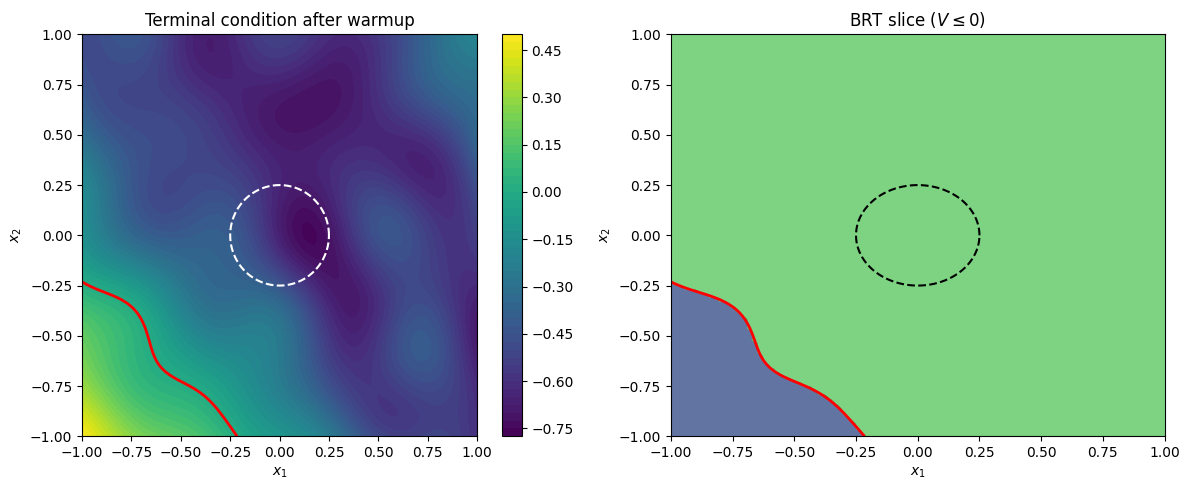

In [71]:
plot_air3d_slice(model, device=device, tau=0.0, x3_value=math.pi / 2, x1_bounds=args.x1_bounds, x2_bounds=args.x2_bounds, nx=101, chunk_size=2048, title="Terminal condition after warmup")

In [72]:
model.loss_manager.loss_weights = {
    "term": 1.0,
    "pinn": 1.0,
    "ic": 0.0,
    "bc": 0.0,
}
dataset_tr.set_tau_max(0.05)

In [73]:
tau_schedule = [0.05, 0.1, 0.2, 0.4, 0.7, 1.0]
steps_per_stage = 700

model.loss_manager.loss_weights = {
    "term": 1.0,
    "pinn": 1.0,
    "ic": 0.0,
    "bc": 0.0,
}

for tau_max in tau_schedule:
    dataset_tr.set_tau_max(tau_max)
    print(f"\nTraining with tau_max = {tau_max:.2f}")

    for step, batch in enumerate(dataloader_tr):
        if step >= steps_per_stage:
            break

        for opt in optimizers.values():
            opt.zero_grad()

        results = model.compute_all_losses(batch, mode="train")
        results["loss_train"].backward()

        torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.ode_func_net.parameters(), max_norm=1.0)

        if "optim_problem" in optimizers:
            problem_params = problem.trainable_parameters()
            if len(problem_params) > 0:
                torch.nn.utils.clip_grad_norm_(problem_params, max_norm=1.0)

        for opt in optimizers.values():
            opt.step()

        if step % 50 == 0:
            print(
                f"step {step:4d} | "
                f"loss={results['loss_train'].item():.3e} | "
                f"term={results['loss_term'].item():.3e} | "
                f"pinn={results['loss_pinn'].item():.3e}"
            )

    plot_air3d_slice(
        model,
        device=device,
        tau=0.0,
        x3_value=math.pi / 2,
        x1_bounds=args.x1_bounds,
        x2_bounds=args.x2_bounds,
        nx=101,
        chunk_size=2048,
        title=f"tau=0.0 after tau_max={tau_max:.2f}",
    )

    plot_air3d_slice(
        model,
        device=device,
        tau=min(tau_max, args.T),
        x3_value=math.pi / 2,
        x1_bounds=args.x1_bounds,
        x2_bounds=args.x2_bounds,
        nx=101,
        chunk_size=2048,
        title=f"tau={tau_max:.2f} slice",
    )


Training with tau_max = 0.05
step    0 | loss=7.444e+00 | term=7.199e-01 | pinn=6.724e+00



KeyboardInterrupt



In [ ]:
plot_air3d(model, device=device, taus=(0.0, 0.5, 1.0), x3_value=math.pi / 2, x1_bounds=args.x1_bounds, x2_bounds=args.x2_bounds, nx=101, chunk_size=2048, mask_plot=True,)